In [2]:
%pip install nltk            

  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [n

In [3]:
import numpy as np 
import pandas as pd 

In [27]:
import nltk

nltk.data.path.append('/home/aidslab109/nltk_data')

nltk.download('stopwords', download_dir='/home/aidslab109/nltk_data')                                                             

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/aidslab109/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
df=pd.read_csv('/home/aidslab109/Downloads/Restaurant_Reviews.tsv',delimiter='\t', quoting=3) 
df.head() 

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [25]:
df.shape 

(1000, 2)

In [29]:
corpus = [] 
for i in range(0,1000): 
    # Cleaning special character from the reviews  
    review = re.sub(pattern='[^a-zA-Z]',repl=' ', string=df['Review'][i]) 
    # Converting the entire review into lower case 
    review = review.lower() 
    # Tokenizing the review by words 
    review_words = review.split() 
    # Removing the stop words 
    review_words = [word for word in review_words if not word in set(stopwords.words('english'))] 
    # Stemming the words 
    ps = PorterStemmer() 
    review = [ps.stem(word) for word in review_words] 
    # Joining the stemmed words 
    review = ' '.join(review) 
    # Creating a corpus 
    corpus.append(review) 
print(corpus[0:10])


['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch']


In [30]:
text = "This movie was really amazing and I enjoyed watching it!"

text = re.sub('[^a-zA-Z]', ' ', text)
text = text.lower()
text = text.split()

text = [ps.stem(word) for word in text if word not in stop_words]

print(text)


['movi', 'realli', 'amaz', 'enjoy', 'watch']


In [31]:
df=pd.read_csv('/home/aidslab109/Desktop/jeevan044/Dataset/Restaurant_Reviews.tsv',delimiter='\t', quoting=3) 
df.head() 

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [13]:
df.shape 

(1000, 2)

In [14]:
corpus = [] 
for i in range(0,1000): 
    # Cleaning special character from the reviews  
    review = re.sub(pattern='[^a-zA-Z]',repl=' ', string=df['Review'][i]) 
    # Converting the entire review into lower case 
    review = review.lower() 
    # Tokenizing the review by words 
    review_words = review.split() 
    # Removing the stop words 
    review_words = [word for word in review_words if not word in set(stopwords.words('english'))] 
    # Stemming the words 
    ps = PorterStemmer() 
    review = [ps.stem(word) for word in review_words] 
    # Joining the stemmed words 
    review = ' '.join(review) 
    # Creating a corpus 
    corpus.append(review) 
print(corpus[0:10])

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch']


In [32]:
# Creating the Bag of Words model 
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=1500) 
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, 1].values

In [33]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.20, random_state = 0) 
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier(n_estimators=35) 
model.fit(X_train, y_train) 
RandomForestClassifier(n_estimators=35) 
model.score(X_test, y_test) 

0.695

In [34]:
# Predicting the Test set results 
y_pred = model.predict(X_test) # Accuracy, Precision and Recall 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import precision_score 
from sklearn.metrics import recall_score 
score1 = accuracy_score(y_test,y_pred) 
score2 = precision_score(y_test,y_pred) 
score3= recall_score(y_test,y_pred) 
print("---- Scores ---- ") 
print("Accuracy score is: {}%".format(round(score1*100,2))) 
print("Precision score is: {}".format(round(score2,2))) 
print("Recall score is: {}".format(round(score3,2))) 

---- Scores ---- 
Accuracy score is: 69.5%
Precision score is: 0.8
Recall score is: 0.54


Text(33.222222222222214, 0.5, 'Actual values')

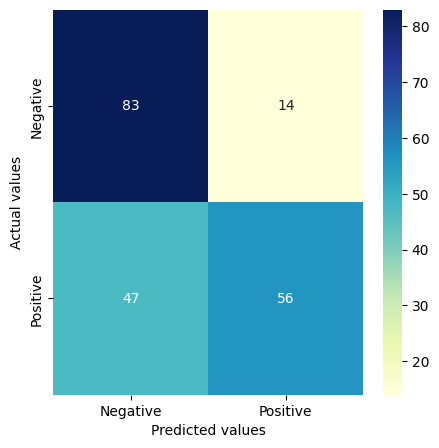

In [36]:
# Making the Confusion Matrix 
from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(y_test, y_pred) 
# Plotting the confusion matrix 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 
plt.figure(figsize = (5,5)) 
sns.heatmap(cm, annot=True, cmap="YlGnBu", xticklabels=['Negative','Positive'], yticklabels=['Negative', 'Positive']) 
plt.xlabel('Predicted values') 
plt.ylabel('Actual values') 

In [20]:
# Hyperparameter tuning the Naive Bayes Classifier
best_accuracy = 0.0 
n_estimators = 5 
for i in np.arange(1,30,2): 
    temp_classifier = RandomForestClassifier(n_estimators=i) 
    temp_classifier.fit(X_train, y_train) 
    temp_y_pred = temp_classifier.predict(X_test) 
    score = accuracy_score(y_test, temp_y_pred) 
    print("Accuracy score for n_estimators={} is: {}%".format(round(i,1),round(score*100,2)))
    if score>best_accuracy: 
        best_accuracy = score 
        n_estimators_val = i 
    print(' ') 
print('The best accuracy is {}% with n_estimators value as {}'.format(round(best_accuracy*100,2), round(n_estimators_val,1))) 

Accuracy score for n_estimators=1 is: 63.5%
 
Accuracy score for n_estimators=3 is: 62.5%
 
Accuracy score for n_estimators=5 is: 69.5%
 
Accuracy score for n_estimators=7 is: 68.5%
 
Accuracy score for n_estimators=9 is: 69.5%
 
Accuracy score for n_estimators=11 is: 70.5%
 
Accuracy score for n_estimators=13 is: 66.5%
 
Accuracy score for n_estimators=15 is: 70.5%
 
Accuracy score for n_estimators=17 is: 71.5%
 
Accuracy score for n_estimators=19 is: 68.5%
 
Accuracy score for n_estimators=21 is: 70.5%
 
Accuracy score for n_estimators=23 is: 71.5%
 
Accuracy score for n_estimators=25 is: 71.5%
 
Accuracy score for n_estimators=27 is: 68.5%
 
Accuracy score for n_estimators=29 is: 69.5%
 
The best accuracy is 71.5% with n_estimators value as 17


In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=19, random_state=42)
model.fit(X_train, y_train)

model


RandomForestClassifier(n_estimators=19, random_state=42)

In [38]:
n_estimators_val = 19

model = RandomForestClassifier(
    n_estimators=n_estimators_val,
    random_state=42
)

model.fit(X_train, y_train)

model


RandomForestClassifier(n_estimators=19, random_state=42)

In [39]:
y_pred = model.predict(X_test)
print(y_pred)


[0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0
 0 0 1 1 1 0 0 0 0 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0
 0 0 0 1 0 0 0 1 0 0 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0 0 0 0 0 0
 0 0 0 0 1 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 0
 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0]


In [40]:
def predict_sentiment(sample_review): 
    sample_review = re.sub(pattern='[^a-zA-Z]',repl=' ', string =sample_review) 
    sample_review = sample_review.lower() 
    sample_review_words = sample_review.split() 
    sample_review_words = [word for word in sample_review_words if not word in set(stopwords.words('english'))] 
    ps = PorterStemmer() 
    final_review = [ps.stem(word) for word in sample_review_words]
    final_review = ' '.join(final_review) 
    temp = cv.transform([final_review]).toarray()
    return model.predict(temp)

In [41]:
sample_review = 'The food is really good here.' 
if predict_sentiment(sample_review): 
    print('This is a POSITIVE review.') 
else: 
    print('This is a NEGATIVE review!') 

This is a POSITIVE review.


In [42]:
sample_review = 'Food was pretty bad and the service was very slow.' 
if predict_sentiment(sample_review): 
    print('This is a POSITIVE review.') 
else: 
    print('This is a NEGATIVE review!') 

This is a NEGATIVE review!


In [43]:
sample_review = 'The food was absolutely wonderful and nicely presentation' 
if predict_sentiment(sample_review): 
    print('This is a POSITIVE review.') 
else: 
    print('This is a NEGATIVE review!') 

This is a POSITIVE review.
